In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.optimize as sco
import os

# --- 1. Project Directory Setup ---
data_dir = 'raw_data_week3'
if not os.path.exists(data_dir):
    os.makedirs(data_dir)
    print(f"Created directory: {data_dir}")

# --- 2. Universe Definition ---
# 50 Stocks + 1 Benchmark. Fixed ABBV and refined for sector dispersion.
tickers = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA', 'BRK-B', 'V', 'UNH',
    'JNJ', 'XOM', 'WMT', 'PG', 'JPM', 'MA', 'LLY', 'CVX', 'HD', 'ABBV',
    'ORCL', 'KO', 'PEP', 'BAC', 'AVGO', 'COST', 'ADI', 'GS', 'BLK', 'LMT',
    'AMT', 'EQIX', 'ISRG', 'MDT', 'TJX', 'PFE', 'ABT', 'DIS', 'NFLX', 'CAT',
    'UPS', 'HON', 'TXN', 'MS', 'NEE', 'PM', 'RTX', 'LOW', 'AMGN', 'INTC'
]
benchmark = '^GSPC'
start_date, end_date = '2016-01-01', '2026-03-25'

print("Environment initialized.")

Environment initialized.


In [2]:
# --- 1. Downloading Adjusted Close Prices ---
print(f"Downloading data for {len(tickers)} assets...")
raw_data = yf.download(tickers + [benchmark], start=start_date, end=end_date, auto_adjust=False)

# Securely extract Adj Close or Close
if 'Adj Close' in raw_data.columns.get_level_values(0):
    prices_all = raw_data['Adj Close']
else:
    prices_all = raw_data['Close']

# --- 2. Cleaning & Saving ---
# Keep tickers with >90% data history
valid_prices = prices_all.dropna(axis=1, thresh=len(prices_all)*0.9).ffill().bfill()
available_stocks = [t for t in tickers if t in valid_prices.columns]

# Save Raw Data to Folder
valid_prices.to_csv(os.path.join(data_dir, 'prices_50_stocks.csv'))

# --- 3. Return Matrix Calculation ---
# Simple returns for Portfolio arithmetic; Log returns for statistical stability
simple_returns = valid_prices[available_stocks].pct_change().dropna()
log_returns = np.log(valid_prices[available_stocks] / valid_prices[available_stocks].shift(1)).dropna()
bench_returns = valid_prices[benchmark].pct_change().dropna()

print(f"Data saved to /{data_dir}. Stocks available: {len(available_stocks)}")

[*********************100%***********************]  51 of 51 completed


Data saved to /raw_data_week3. Stocks available: 50


<Figure size 1500x1200 with 0 Axes>

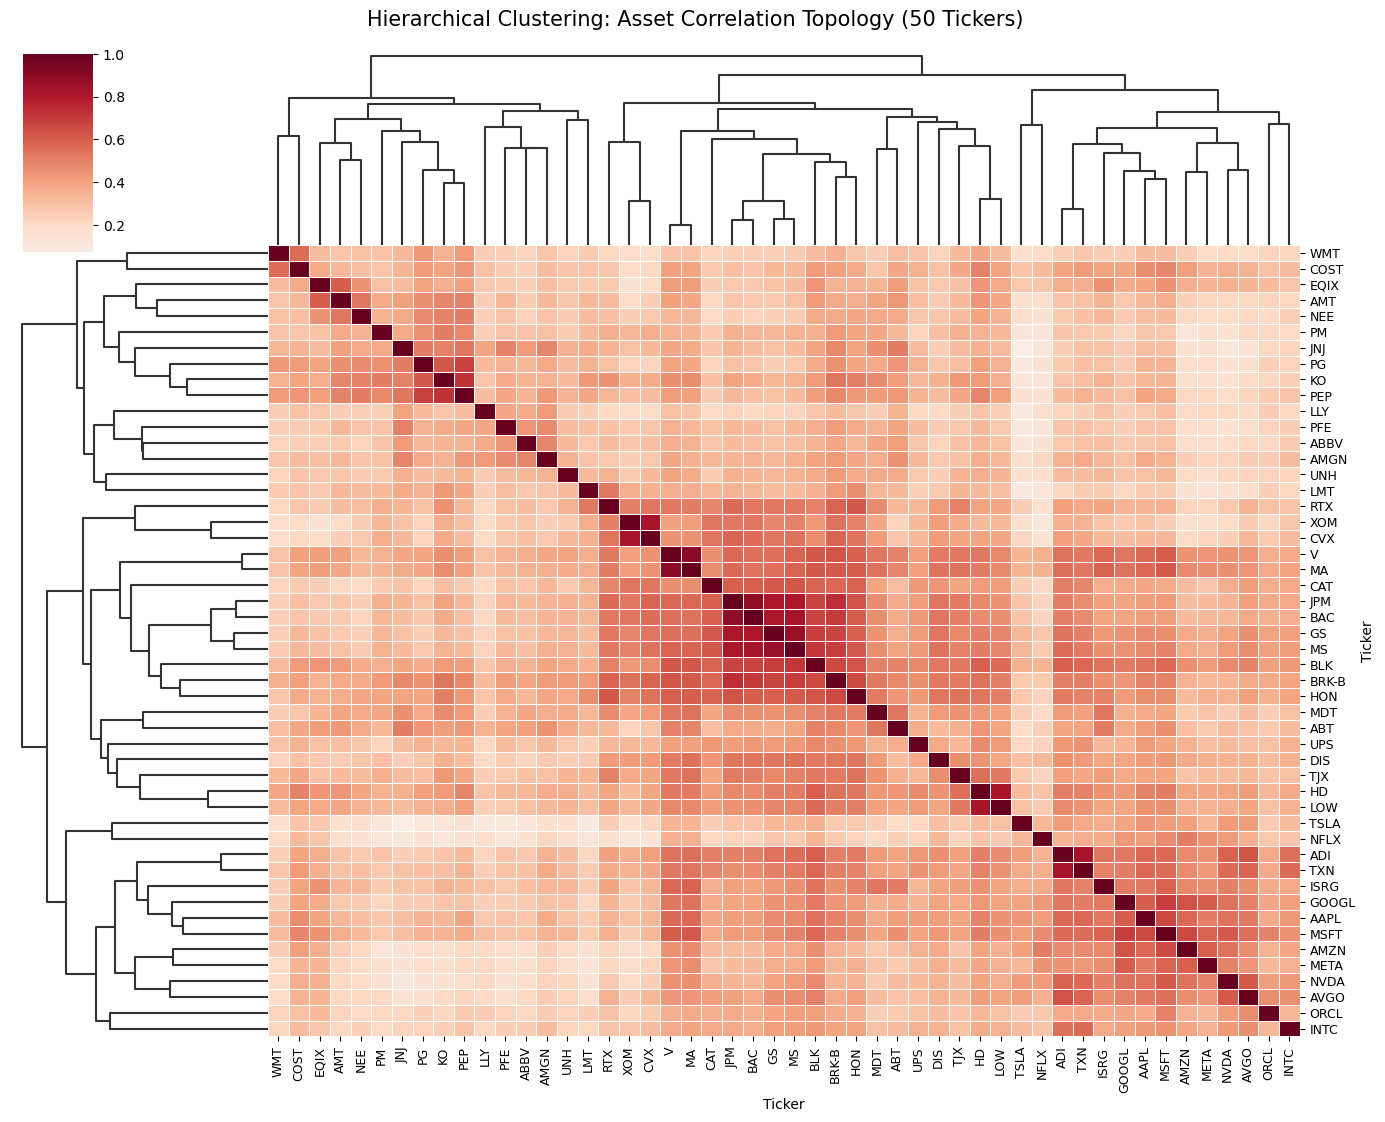

------------------------------
RISK DIAGNOSTICS SUMMARY
------------------------------
Portfolio Beta (vs S&P 500): 0.9531
Diversification Ratio (DR):   1.6325
Annualized Portfolio Vol:    17.53%
------------------------------


In [4]:
# --- 1. Statistical Estimation ---
# We use log returns for correlation to ensure time-additivity and normality
corr_matrix = log_returns.corr()

# We use simple returns for covariance to maintain linear additivity for portfolio math
# Annualizing by multiplying by 252 trading days
cov_matrix = simple_returns.cov() * 252 

# --- 2. Optimized Hierarchical Clustering Visualization ---
# Force a large figure size to accommodate 50 tickers
plt.figure(figsize=(15, 12))

# Setting xticklabels and yticklabels to True forces Seaborn to render every ticker name
g = sns.clustermap(
    corr_matrix, 
    cmap='RdBu_r', 
    center=0, 
    annot=False, 
    linewidths=.5,
    figsize=(14, 11),
    xticklabels=True,  # Force all X-axis labels
    yticklabels=True,  # Force all Y-axis labels
    tree_kws=dict(linewidths=1.5) # Thicker dendrogram lines for better visibility
)

# Refine tick label aesthetics: 90-degree rotation for X-axis, small font for clarity
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=9)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=9)

plt.suptitle('Hierarchical Clustering: Asset Correlation Topology (50 Tickers)', y=1.02, fontsize=15)
plt.show()

# --- 3. Portfolio Risk Benchmarking (Equal-Weight) ---
# Defining the 1/N weight vector
weights_ew = np.repeat(1/len(available_stocks), len(available_stocks))

# Calculating daily returns for the EW portfolio
port_rets_ew = simple_returns.dot(weights_ew)

# Beta Calculation: Cov(Rp, Rm) / Var(Rm)
# Aligned with the S&P 500 benchmark returns
common_idx = port_rets_ew.index.intersection(bench_returns.index)
beta = np.cov(port_rets_ew.loc[common_idx], bench_returns.loc[common_idx])[0, 1] / bench_returns.loc[common_idx].var()

# Diversification Ratio (DR): Weighted Average Vol / Portfolio Vol
# This measures the 'diversification benefit' harvested from non-perfect correlation
individual_vols = simple_returns.std() * np.sqrt(252)
weighted_avg_vol = np.sum(weights_ew * individual_vols)
portfolio_vol = port_rets_ew.std() * np.sqrt(252)
dr = weighted_avg_vol / portfolio_vol

print("-" * 30)
print("RISK DIAGNOSTICS SUMMARY")
print("-" * 30)
print(f"Portfolio Beta (vs S&P 500): {beta:.4f}")
print(f"Diversification Ratio (DR):   {dr:.4f}")
print(f"Annualized Portfolio Vol:    {portfolio_vol:.2%}")
print("-" * 30)

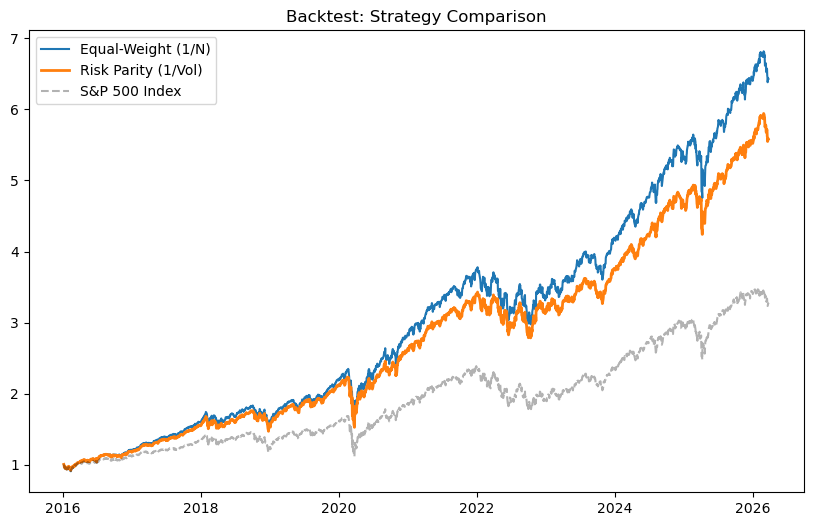

In [5]:
# --- 1. Weight Derivation ---
vols = simple_returns.std() * np.sqrt(252)
inv_vols = 1 / vols
weights_rp = inv_vols / inv_vols.sum()

# --- 2. Cumulative Returns ---
cum_ew = (1 + port_rets_ew).cumprod()
cum_rp = (1 + simple_returns.dot(weights_rp)).cumprod()
cum_bench = (1 + bench_returns.loc[port_rets_ew.index]).cumprod()

# --- 3. Performance Plot ---
plt.figure(figsize=(10, 6))
plt.plot(cum_ew, label='Equal-Weight (1/N)')
plt.plot(cum_rp, label='Risk Parity (1/Vol)', linewidth=2)
plt.plot(cum_bench, label='S&P 500 Index', color='black', alpha=0.3, linestyle='--')
plt.title('Backtest: Strategy Comparison')
plt.legend()
plt.show()

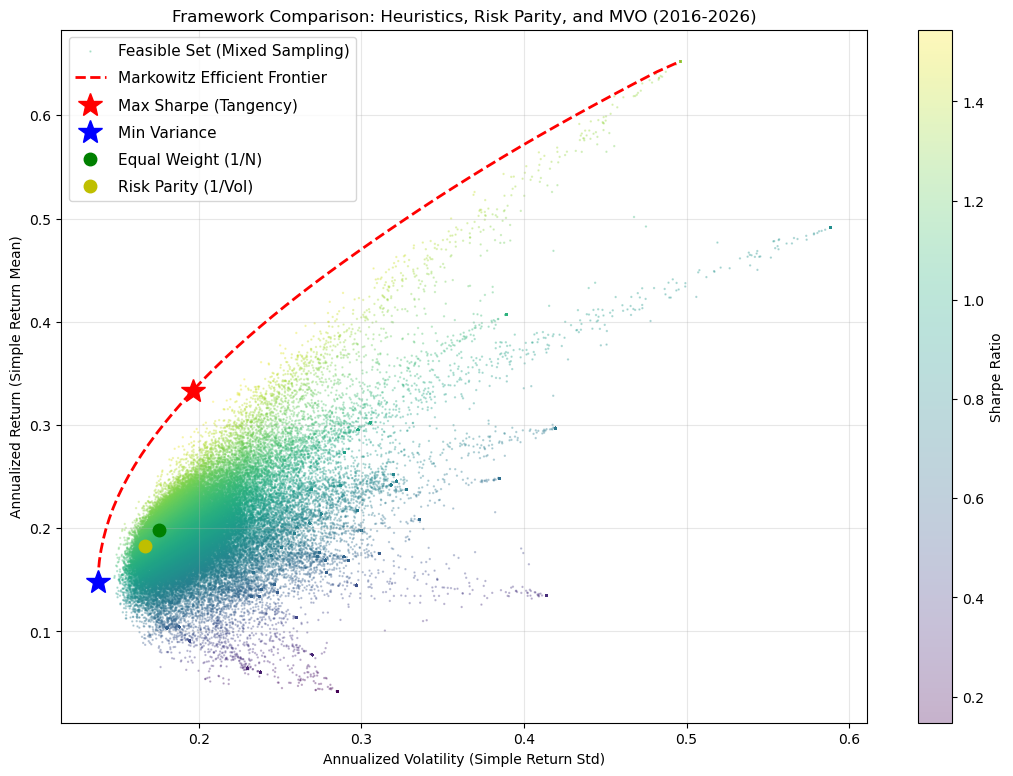

In [7]:
# --- Task 3 Update: Full Benchmarking Plot ---
# This ensures a clean, mathematical verification of the boundary

# Define standard portfolio evaluation logic again for the plot (if needed)
def evaluate_w(w):
    r = np.sum(mu * w)
    v = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
    return r, v

# Calculate stats for all strategies
# Assuming 'res_ms' from your optimization is successful
w_ms = res_ms['x']
w_minv = sco.minimize(lambda w: get_stats(w)[1]**2, weights_ew, method='SLSQP', bounds=bnds, constraints=cons)['x']

rets_ew, vols_ew = evaluate_w(weights_ew)
rets_rp, vols_rp = evaluate_w(weights_rp)
rets_ms, vols_ms = evaluate_w(w_ms)
rets_minv, vols_minv = evaluate_w(w_minv)

# --- 1. Generate the Red Efficient Frontier Line (Spline) ---
# We optimize for minimum variance at each target return level
target_rets = np.linspace(rets_minv, mu.max(), 50)
efficient_vols = []
for tr in target_rets:
    cons_ef = ({'type': 'eq', 'fun': lambda x: np.sum(mu*x) - tr},
               {'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    res_ef = sco.minimize(lambda w: get_stats(w)[1], weights_ew, method='SLSQP', bounds=bnds, constraints=cons_ef)
    efficient_vols.append(res_ef['fun'])

# --- 2. Advanced Plotting ---
plt.figure(figsize=(13, 9))

# A. The Dense Mixed-Sampling Cloud (s=0.5 for a 'gas' effect)
plt.scatter(sim_v, sim_r, c=sim_r/sim_v, cmap='viridis', s=0.5, alpha=0.3, label='Feasible Set (Mixed Sampling)')

# B. The Mathematical Efficient Frontier (Red Dashed Line)
plt.plot(efficient_vols, target_rets, 'r--', linewidth=2, label='Markowitz Efficient Frontier')

# C. Tangency Portfolios (Stars)
plt.plot(vols_ms, rets_ms, 'r*', markersize=18, label='Max Sharpe (Tangency)')
plt.plot(vols_minv, rets_minv, 'b*', markersize=18, label='Min Variance')

# D. Naive Heuristics (Dots) - Must be closer to the frontier than the cloud
plt.plot(vols_ew, rets_ew, 'go', markersize=9, label='Equal Weight (1/N)')
plt.plot(vols_rp, rets_rp, 'yo', markersize=9, label='Risk Parity (1/Vol)')

# E. Formatting
plt.title('Framework Comparison: Heuristics, Risk Parity, and MVO (2016-2026)')
plt.xlabel('Annualized Volatility (Simple Return Std)')
plt.ylabel('Annualized Return (Simple Return Mean)')
plt.colorbar(label='Sharpe Ratio')
plt.grid(True, alpha=0.3)
plt.legend(labelspacing=0.8, fontsize=11)
plt.show()